In [2]:
print("hello")

hello


### Missing value 

Missing value accurs in dataset when some of the information is not stored for the variable .There are 3 Machanism

## 1. Missing completely at random ,MCAR:

Missing completely at random is a type of missing data mecahnism in which the probabilty of the value being missing is unrelated to both the observed data and the missing data.In other words if the data is MCAR, the missing value are randomly distributed throughout the dataset, and there is no systematic reason for why they are missing.

#### for Example:-
in survey about the prevelance of certain disease, the missing data might be MCAR if the survey paticipants with missing values for certain questions were selected randomly and their missing response are not related to their disease satus on any other variable measured in the survey.

## 2. Missing at random ,MAR:
missing at random is the type of missing data machanism in which the probility of the value being missing is depend only on the observed data,but not on the missing data itself. in other words if the data is MAR, the missing value is systematically related to the observed data,but not the missing the data. Here are few example

Income Data:suppose you are collecting income data froma group of people, but some participant choose not to report their income. If the decision  to report or not report income is related to the participant age or gender,but not to their income level,then the data is missing at random.

Medical Data: Suppose you are collocting medical data on patients, including their blood pressure but some pateint do not report their blood pressure.if the patient who does not report their blood pressure are more likely to be younger or have healtier life styles, but the missigness is not related to their actual blood pressure values, then the data is missing at random.


## 3. Missing data not at random (MNAR):

It is type of missing data machanism where the probabilty of missing values depends on the value of missing data itself. In other words,if the data is MNAR the missingess is not random and is dependent on unobserved or unmesaured factors that are associated with the missing value.

for Example:- suppose you are collecting data on the income and jobs satisfaction of employees in a company . If employees who are less satisfied with their jobs are most likely to refuese to report  their income, then the data is not missing at random. in this case the missingess is dependent on job satisfacation, which is not directly observed or measured.

In [3]:
import seaborn as sns


In [5]:
df = sns.load_dataset('titanic')

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
# checking missing values 

missing_values = df.isnull()
missing_values

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
missing_values.sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
# One easy way to handle missing values is to drop the rows with missing values. This can be done using the dropna() function.
# the problem with this approach is that we may lose a lot of data if there are many missing values. 
# So, we need to be careful while using this approach.

df.shape

(891, 15)

In [14]:
df.dropna().shape

(182, 15)

In [15]:
# colums wise deletion
df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


## Imputation missing values

#### 1. Mean value Imputation 

<Axes: xlabel='age', ylabel='Count'>

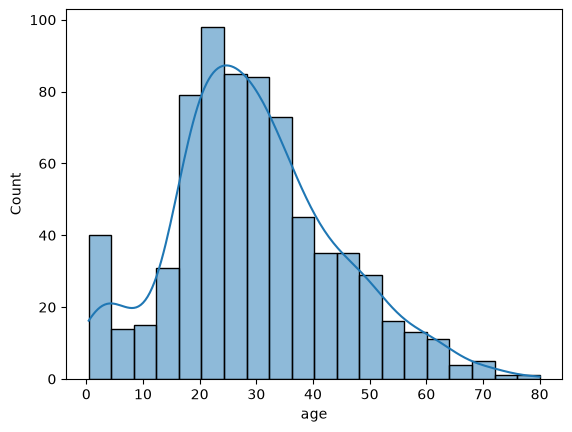

In [17]:
sns.histplot(df['age'],kde=True)

In [20]:
df['age_mean']=df['age'].fillna(df['age'].mean())
df[['age_mean','age']]

,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [23]:
# Mean imputation works well when we have a normally distributed data.

### 2.Median value Imputation -- if we have outliers in the dataset.

In [25]:
df['age_median']=df['age'].fillna(df['age'].median())
df[['age_mean','age_median','age']]

,age_mean,age_median,age
0,22.000000,22.0,22.0
1,38.000000,38.0,38.0
2,26.000000,26.0,26.0
3,35.000000,35.0,35.0
4,35.000000,35.0,35.0
...,...,...,...
886,27.000000,27.0,27.0
887,19.000000,19.0,19.0
888,29.699118,28.0,NaN
889,26.000000,26.0,26.0


### Mode imputation technique -- Categorial Values

In [26]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [27]:
df['embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [ ]:
df['mode_value']=df[df['embarked'].notna()]['embarked'].mode()[0]

In [ ]:
df['embarked_value']=df['embarked'].fillna('mode_vaue')

In [36]:
df[['embarked','embarked_value']]

,embarked,embarked_value
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [39]:
df['embarked_value'].isnull().sum()

np.int64(0)

In [40]:
df['embarked'].isnull().sum()

np.int64(2)